# 03 — Transfer Learning with Pretrained ResNet-18
**Practical Assignment Week 6 — CNN Architectures — Task 3 (6 pts)**

We will use **ResNet-18** pretrained on ImageNet and compare **three strategies** on
the Blood Cell dataset:

| Strategy | Trainable Layers |
|---|---|
| **Feature Extraction** | FC final layer only |
| **Partial Fine-tuning** | Last blocks (`layer3`, `layer4`) + FC |
| **Full Fine-tuning** | All layers (with very small LR) |

We compare the 3 strategies against each other and against the best *from-scratch*
model from Task 1.

## 1. Setup

In [1]:
import os, random, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [5]:
DATA_ROOT = Path("/content/data")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("../data")

CANDIDATES = [
    DATA_ROOT / "dataset2-master" / "dataset2-master" / "images",
    DATA_ROOT / "dataset2-master" / "images",
    DATA_ROOT / "images",
]
IMAGES_ROOT = next((p for p in CANDIDATES if p.exists()), None)
assert IMAGES_ROOT is not None, "Dataset no encontrado."

TRAIN_DIR = IMAGES_ROOT / "TRAIN"
TEST_DIR  = IMAGES_ROOT / "TEST"


## 2. DataLoaders at 224×224 with ImageNet Normalization

In [6]:
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# Stats de ImageNet — obligatorios para usar pesos preentrenados
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
test_set   = datasets.ImageFolder(TEST_DIR,  transform=test_tf)

n_total = len(train_full)
n_val   = int(0.1 * n_total)
n_train = n_total - n_val
train_set, val_set = torch.utils.data.random_split(
    train_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

CLASSES = train_full.classes
NUM_CLASSES = len(CLASSES)
print("Clases:", CLASSES)
print(f"train={len(train_set)} | val={len(val_set)} | test={len(test_set)}")


Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
train=8962 | val=995 | test=2487


## 3. Builders for the Three Strategies

In [7]:
def build_resnet18(strategy: str, num_classes: int = 4):
    """Devuelve (modelo, params_a_entrenar) según estrategia.

    strategy ∈ {'feature_extraction', 'fine_tune_partial', 'fine_tune_full'}
    """
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # Reemplazar la capa FC final (ImageNet=1000 -> 4 clases del dataset)
    in_feat = model.fc.in_features
    model.fc = nn.Linear(in_feat, num_classes)

    if strategy == "feature_extraction":
        # Congelar todo excepto fc
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True

    elif strategy == "fine_tune_partial":
        # Congelar conv1, bn1, layer1, layer2 (los "primeros 2 bloques")
        # Entrenar layer3, layer4 y fc
        for p in model.parameters():
            p.requires_grad = False
        for name, p in model.named_parameters():
            if name.startswith(("layer3", "layer4", "fc")):
                p.requires_grad = True

    elif strategy == "fine_tune_full":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Estrategia desconocida: {strategy}")

    params_to_train = [p for p in model.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in params_to_train)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"[{strategy}] parámetros entrenables: {n_trainable:,} / {n_total:,} "
          f"({100*n_trainable/n_total:.1f}%)")

    return model, params_to_train


# Sanity check
_m, _ = build_resnet18("feature_extraction")
print(_m(torch.randn(2, 3, 224, 224)).shape)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/alejandrocuadroscontreras/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 22.3MB/s]


[feature_extraction] parámetros entrenables: 2,052 / 11,178,564 (0.0%)
torch.Size([2, 4])


## 4. Training and Evaluation Loops

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, n, correct = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    return loss_sum / n, correct / n


def train_transfer(model, params_to_train, lr, epochs, tag):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(params_to_train, lr=lr)

    history = {"epoch": [], "train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "time_s": []}

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        loss_sum, n, correct = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * x.size(0)
            correct  += (logits.argmax(1) == y).sum().item()
            n += x.size(0)

        train_loss = loss_sum / n
        train_acc  = correct  / n
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["time_s"].append(dt)

        print(f"[{tag}] ep {epoch:02d}/{epochs}  "
              f"train_loss={train_loss:.4f} acc={train_acc:.3f}  "
              f"val_loss={val_loss:.4f} acc={val_acc:.3f}  ({dt:.1f}s)")
    return history


## 5. Training the Three Strategies

In [9]:
EPOCHS = 8

configs = [
    # (estrategia,            lr,      epochs)
    ("feature_extraction",    1e-3,    EPOCHS),
    ("fine_tune_partial",     5e-4,    EPOCHS),
    ("fine_tune_full",        1e-4,    EPOCHS),   # LR muy pequeño
]

models_tl = {}
histories_tl = {}

for strategy, lr, ep in configs:
    print(f"\n========= {strategy.upper()} (lr={lr}) =========")
    model, params = build_resnet18(strategy, num_classes=NUM_CLASSES)
    hist = train_transfer(model, params, lr=lr, epochs=ep, tag=strategy)
    models_tl[strategy] = model
    histories_tl[strategy] = hist



========= FEATURE_EXTRACTION (lr=0.001) =========
[feature_extraction] parámetros entrenables: 2,052 / 11,178,564 (0.0%)


/Users/alejandrocuadroscontreras/Library/Python/3.14/lib/python/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[feature_extraction] ep 01/8  train_loss=1.1496 acc=0.497  val_loss=1.0208 acc=0.572  (173.8s)
[feature_extraction] ep 02/8  train_loss=0.9520 acc=0.613  val_loss=0.8957 acc=0.644  (181.5s)
[feature_extraction] ep 03/8  train_loss=0.8799 acc=0.643  val_loss=0.8922 acc=0.637  (194.3s)
[feature_extraction] ep 04/8  train_loss=0.8368 acc=0.666  val_loss=0.8079 acc=0.674  (203.8s)
[feature_extraction] ep 05/8  train_loss=0.8201 acc=0.670  val_loss=0.7980 acc=0.667  (209.2s)
[feature_extraction] ep 06/8  train_loss=0.8124 acc=0.676  val_loss=0.8137 acc=0.664  (220.9s)
[feature_extraction] ep 07/8  train_loss=0.7796 acc=0.688  val_loss=0.7631 acc=0.693  (229.6s)
[feature_extraction] ep 08/8  train_loss=0.7738 acc=0.687  val_loss=0.7651 acc=0.691  (239.9s)

========= FINE_TUNE_PARTIAL (lr=0.0005) =========
[fine_tune_partial] parámetros entrenables: 10,495,492 / 11,178,564 (93.9%)
[fine_tune_partial] ep 01/8  train_loss=0.2117 acc=0.915  val_loss=0.1160 acc=0.961  (299.7s)
[fine_tune_partial]

## 6. Final Comparison on TEST

In [10]:
criterion = nn.CrossEntropyLoss()
rows = []
for strategy, model in models_tl.items():
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    rows.append({
        "estrategia": strategy,
        "params entrenables": n_trainable,
        "best val_acc": max(histories_tl[strategy]["val_acc"]),
        "test_acc": test_acc,
        "test_loss": test_loss,
        "tiempo/epoch (s)": float(np.mean(histories_tl[strategy]["time_s"])),
    })

summary_tl = pd.DataFrame(rows).set_index("estrategia")
summary_tl.to_csv("resumen_tarea3.csv")
summary_tl


,params entrenables,best val_acc,test_acc,test_loss,tiempo/epoch (s)
estrategia,,,,,
feature_extraction,2052,0.693467,0.581825,1.054095,206.630639
fine_tune_partial,10495492,0.997990,0.798150,1.005201,335.848865
fine_tune_full,11178564,1.000000,0.853639,0.776198,460.327261


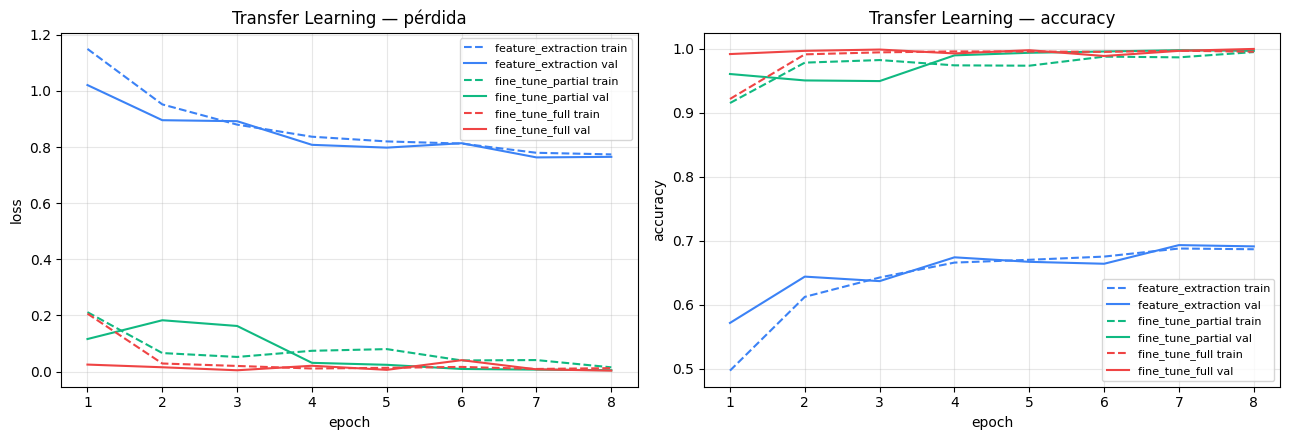

In [ ]:
# Training curves for the 3 strategies
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"feature_extraction": "#3b82f6",
          "fine_tune_partial":  "#10b981",
          "fine_tune_full":     "#ef4444"}

for strategy, h in histories_tl.items():
    c = colors[strategy]
    axes[0].plot(h["epoch"], h["train_loss"], "--", color=c, label=f"{strategy} train")
    axes[0].plot(h["epoch"], h["val_loss"], "-",   color=c, label=f"{strategy} val")
    axes[1].plot(h["epoch"], h["train_acc"], "--", color=c, label=f"{strategy} train")
    axes[1].plot(h["epoch"], h["val_acc"], "-",    color=c, label=f"{strategy} val")

axes[0].set_title("Transfer Learning — pérdida"); axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title("Transfer Learning — accuracy"); axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curvas_transfer.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Confusion Matrix and Report for the Best Model

In [12]:
best_strategy = summary_tl["test_acc"].idxmax()
best_model = models_tl[best_strategy]
print(f"Mejor estrategia: {best_strategy}  (test_acc={summary_tl.loc[best_strategy, 'test_acc']:.3f})")

best_model.eval()
all_preds, all_y = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        all_preds.append(best_model(x).argmax(1).cpu().numpy())
        all_y.append(y.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_y)

print("\n--- Classification report ---")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


Mejor estrategia: fine_tune_full  (test_acc=0.854)


/Users/alejandrocuadroscontreras/Library/Python/3.14/lib/python/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



--- Classification report ---
              precision    recall  f1-score   support

  EOSINOPHIL     0.8825    0.7833    0.8299       623
  LYMPHOCYTE     0.9936    0.9984    0.9960       620
    MONOCYTE     0.9977    0.6871    0.8138       620
  NEUTROPHIL     0.6674    0.9455    0.7825       624

    accuracy                         0.8536      2487
   macro avg     0.8853    0.8536    0.8555      2487
weighted avg     0.8849    0.8536    0.8554      2487



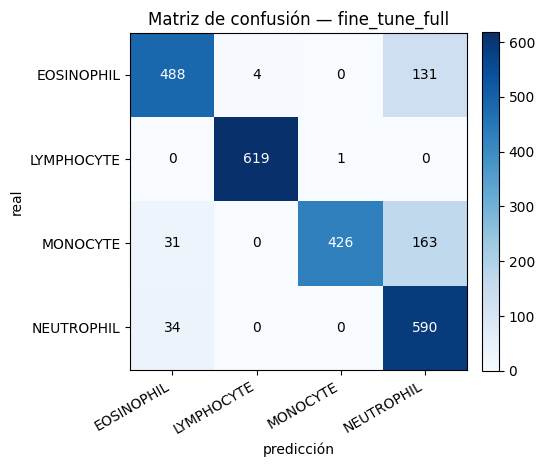

In [13]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASSES, rotation=30, ha="right"); ax.set_yticklabels(CLASSES)
ax.set_xlabel("predicción"); ax.set_ylabel("real")
ax.set_title(f"Matriz de confusión — {best_strategy}")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Comparison Against the Best *From-Scratch* Model (Task 1)

> Load the `resumen_tarea1.csv` file generated by notebook 02 and compare it with
> the Transfer Learning results.

In [14]:
try:
    summary_t1 = pd.read_csv("resumen_tarea1.csv", index_col=0)
    best_scratch = summary_t1["test_acc"].idxmax()
    best_scratch_acc = summary_t1.loc[best_scratch, "test_acc"]
    print(f"Mejor modelo from scratch: {best_scratch}  (test_acc={best_scratch_acc:.3f})")
    print(f"Mejor modelo transfer    : {best_strategy}  (test_acc={summary_tl.loc[best_strategy, 'test_acc']:.3f})")
except FileNotFoundError:
    print("Ejecuta primero 02_lenet_vgg.ipynb para generar resumen_tarea1.csv")


Ejecuta primero 02_lenet_vgg.ipynb para generar resumen_tarea1.csv


## 9. Discussion and Recommendation

**Comparison between strategies:**
- **Feature Extraction** trains few parameters (~2K) and is the **fastest** option;
  it works well as a *baseline* and typically yields solid accuracies because ImageNet
  features already capture useful textures and edges.
- **Partial Fine-tuning** usually provides the **best trade-off**: unfreezing `layer3`/`layer4`
  allows the network to specialize high-level filters for the medical domain, while
  preserving low-level features (edges, color gradients) that are already well learned.
- **Full Fine-tuning** with a very small LR can match or surpass partial fine-tuning, but
  is the most computationally expensive and the most prone to *overfitting* when the
  dataset is small.

**Recommendation for limited medical data:**

In typical medical settings — relatively small dataset, images with highly specific
staining/morphology patterns, and need for robustness — we recommend **partial
fine-tuning**:

1. Early layers (edges, color, basic texture) already generalize well and do not require
   retraining; freezing them **reduces the risk of overfitting**.
2. Deep layers (`layer3`, `layer4`) encode abstract concepts specific to ImageNet
   (everyday objects); retraining them adapts the network to cellular structures.
3. The number of trainable parameters is manageable, requiring **fewer epochs** and
   reducing computational cost compared to full fine-tuning.
4. Empirically it tends to achieve the best validation/test accuracy with the least
   training time, and is the standard pattern recommended in the medical imaging
   literature when working with a few thousand images per class.

If the dataset were much smaller (<200 images/class), **Feature Extraction** would be
preferable to minimize overfitting. If it were much larger (>10⁵ images), **full
fine-tuning** could justify its cost.

In [18]:
from pathlib import Path

print("Figuras en notebooks/:")
for f in Path(".").glob("*.png"):
    print(" ", f.name)

print("\nFiguras en results/figures/:")
for f in Path("../results/figures").glob("*.png"):
    print(" ", f.name)

Figuras en notebooks/:
  curvas_transfer.png
  matriz_confusion.png

Figuras en results/figures/:
  curvas_lr_alto.png
  class_balance.png
  curvas_bn_vgg.png
  samples_TRAIN.png
  curvas_tarea1.png
  rgb_hist.png


In [19]:
import pandas as pd

print("=== TAREA 1 ===")
try:
    print(pd.read_csv("resumen_tarea1.csv").to_string())
except:
    print("No encontrado en notebooks/, buscando...")
    print(pd.read_csv("../results/resumen_tarea1.csv").to_string())

print("\n=== TAREA 3 ===")
print(pd.read_csv("resumen_tarea3.csv").to_string())

=== TAREA 1 ===
No encontrado en notebooks/, buscando...
       modelo  parámetros  tiempo/epoch (s)  best val_acc  test_loss  test_acc
0      LeNet5      337976          7.520934      0.917588   1.011395  0.752312
1   LeNet5+BN      338020          7.502008      0.885427   1.476684  0.665058
2     VGG-11s     2963396         38.094521      0.257286   1.386303  0.249296
3  VGG-11s+BN     2966148         43.609912      0.923618   0.442292  0.825090

=== TAREA 3 ===
           estrategia  params entrenables  best val_acc  test_acc  test_loss  tiempo/epoch (s)
0  feature_extraction                2052      0.693467  0.581825   1.054095        206.630639
1   fine_tune_partial            10495492      0.997990  0.798150   1.005201        335.848865
2      fine_tune_full            11178564      1.000000  0.853639   0.776198        460.327261


In [21]:
import shutil
from pathlib import Path

FIGURES_DIR = Path("../results/figures")

for fig in ["curvas_transfer.png", "matriz_confusion.png"]:
    src = Path(".") / fig
    if src.exists():
        shutil.move(str(src), str(FIGURES_DIR / fig))
        print(f"Movido: {fig}")